https://github.com/sihsieh65-tech/cs82a-portfolio/tree/main/Module4

Step 1: Load your clean data. One notable issue is that the file while saved after all cleaning steps appear to load and changes my zip data back to an int64. I correct for this in the analysis. 

In [1]:
import pandas as pd
df = pd.read_csv('sales_clean.csv')
df

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405
...,...,...,...,...,...,...
287,1103,2026-04-21,pen set,16.47,3,90405
288,1067,2026-04-27,backpack,37.93,5,90210
289,1025,2026-04-27,keyboard,47.30,2,2116
290,1196,2026-04-25,pen set,8.79,3,90405


In [2]:
df.shape

(292, 6)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 13.8 KB


In [4]:
df["zip"] = df["zip"].astype(str).str.zfill(5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    str    
 2   product   292 non-null    str    
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 13.8 KB


Step 2: Center and spread of price and qty

In [6]:
print(df["price"].mean())
print(df["price"].median())
print(df["price"].std())

55.52315068493151
37.53
71.76708493504132


In [7]:
print(df["qty"].mean())
print(df["qty"].median())
print(df["qty"].std())

2.9863013698630136
3.0
1.4092785381929205


Step 3: Which summary would you report? (markdown cell)
I would report the median as the data appears to be heavily skewed, therefore the mean would be biased towards the high-end (left-tailed skew). 

Step 4: Histogram of price

<Axes: ylabel='Frequency'>

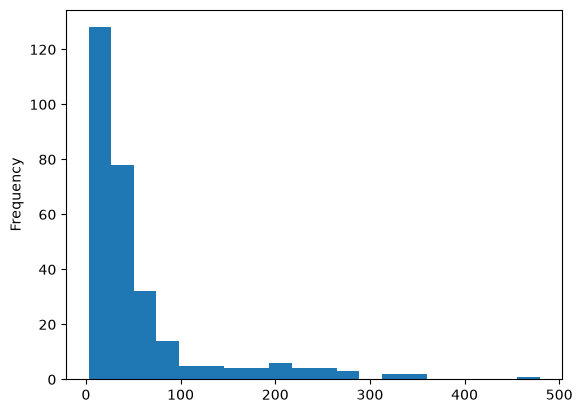

In [8]:
df["price"].plot(kind="hist", bins=20)


Step 5: Create the revenue column

In [9]:
df["revenue"] = df["price"] * df["qty"]

In [10]:
df

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36
...,...,...,...,...,...,...,...
287,1103,2026-04-21,pen set,16.47,3,90405,49.41
288,1067,2026-04-27,backpack,37.93,5,90210,189.65
289,1025,2026-04-27,keyboard,47.30,2,02116,94.60
290,1196,2026-04-25,pen set,8.79,3,90405,26.37


Step 6: Correlation matrix

In [11]:
df.corr(numeric_only=True)

,order_id,price,qty,revenue
order_id,1.000000,-0.005070,0.031420,0.004181
price,-0.005070,1.000000,-0.041982,0.821001
qty,0.031420,-0.041982,1.000000,0.312793
revenue,0.004181,0.821001,0.312793,1.000000


Step 7: Scatter to verify

<Axes: xlabel='qty', ylabel='revenue'>

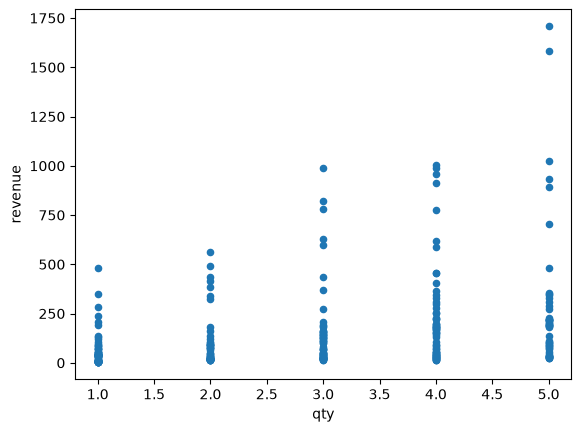

In [12]:
df.plot.scatter(x="qty", y="revenue")

Step 8: The analyst’s sentence (markdown cell)

I would be very skeptical of any conclusions reached using this data. The plots clearly show data stacked on top of each other and the range of revenues based on the quantities sold vary quite a bit. The pearson's coefficient is 0.31 which is below the 0.5 normally needed to consider a correlation to be strong. Secondly, we know that the revenue is calculated using the quantity which basically forces there to be some correlation between quantity and revenue.  

Step 9: By-hand check, then verified using python

Mean and median of: [2, 4, 4, 6, 9]

The sum of the values is 25, divided by 5 values equals 5. The values are already sorted and the middle value is four. 
Therefore:

Mean is 5.0, median is 4

In [13]:
import statistics

numbers = [2, 4, 4, 6, 9]

mean_val = statistics.mean(numbers)
median_val = statistics.median(numbers)

print(f"Mean: {mean_val}")      
print(f"Median: {median_val}")

Mean: 5
Median: 4
